# 🔬 RUN_BUENO-STS: Análisis de Runs Individuales STS

**Notebook parametrizable para analizar runs individuales de sensores Frame (STS).**

Basado en la estructura de `RUN_BUENO.ipynb` pero usando `runSTS.py` y con capacidad de filtrar por patrones.

## 📋 Cómo usar

1. **Celda 1**: Setup de paths
2. **Celda 2**: Cargar LogFile
3. **Celda 3**: **MODIFICAR AQUÍ** - Ajusta filtros y selecciona archivo
4. **Celdas 4-7**: Ejecutar análisis

## 🎯 Parámetros (Celda 3)

- `FILENAME_PATTERN = 'STS'` → Filtra por nombre
- `CALIBSET_PATTERN = 'FRAME_SET'` → Filtra por CalibSetNumber
- `EXCLUDE_PATTERNS = ['_pre', 'lar']` → Excluye patrones
- `filename = "..."` → Archivo a analizar

In [1]:
# Add repo root to sys.path so the package can be imported in-kernel without reinstalling
import sys
from pathlib import Path
repo_root = (Path('../..').resolve())  # notebook is RTD_Calibration_VGP/notebooks -> go up 2 levels
sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

# Now you can import modules from the package via the package namespace


Inserted repo root into sys.path: /Users/vicky/Desktop/rtd-calibration-ana


In [2]:
# Import local modules via package namespace
from RTD_Calibration_VGP.src.logfile import Logfile
from RTD_Calibration_VGP.src.runSTS import Run  # ← Usamos runSTS.py
import pandas as pd

# Read the logfile using repo_root from previous cell
logfile_path = (repo_root / 'RTD_Calibration_VGP' / 'data' / 'LogFile.csv').resolve()
if not logfile_path.exists():
    print(f'Warning: logfile not found at {logfile_path}')
    logfile_df = pd.DataFrame()
else:
    logfiles = Logfile(filepath=str(logfile_path))
    logfile_df = logfiles.log_file
    print("✅ Logfile loaded")
    print(f"   Total rows: {len(logfile_df)}")

CSV file loaded successfully from '/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/LogFile.csv'.
✅ Logfile loaded
   Total rows: 811


In [3]:
# ═══════════════════════════════════════════════════════════════
# 🎛️  CONFIGURACIÓN - MODIFICAR AQUÍ
# ═══════════════════════════════════════════════════════════════

FILENAME_PATTERN = 'STS'           # Filtra por nombre de archivo
CALIBSET_PATTERN = 'FRAME_SET'     # Filtra por CalibSetNumber
EXCLUDE_PATTERNS = ['_pre', 'lar'] # Excluye estos patrones

# ═══════════════════════════════════════════════════════════════
# 🔍 FILTRADO AUTOMÁTICO
# ═══════════════════════════════════════════════════════════════

print(f"\n📊 Aplicando filtros...\n")
filtered_df = logfile_df.copy()

if FILENAME_PATTERN:
    filtered_df = filtered_df[filtered_df['Filename'].str.contains(FILENAME_PATTERN, case=False, na=False)]
    print(f"🔍 Filtro 1: Filename contiene '{FILENAME_PATTERN}' → {len(filtered_df)} archivos")

if CALIBSET_PATTERN:
    filtered_df = filtered_df[filtered_df['CalibSetNumber'].astype(str).str.contains(CALIBSET_PATTERN, case=False, na=False)]
    print(f"🔍 Filtro 2: CalibSetNumber contiene '{CALIBSET_PATTERN}' → {len(filtered_df)} archivos")

for exclude in EXCLUDE_PATTERNS:
    before = len(filtered_df)
    filtered_df = filtered_df[~filtered_df['Filename'].str.contains(exclude, case=False, na=False)]
    excluded = before - len(filtered_df)
    if excluded > 0:
        print(f"🚫 Filtro 3: Excluidos {excluded} archivos con '{exclude}' → {len(filtered_df)} archivos")

print(f"\n📋 Total archivos disponibles: {len(filtered_df)}\n")

if len(filtered_df) > 0:
    print(f"📌 Primeros 10 archivos disponibles:\n")
    for idx, row in filtered_df.head(10).iterrows():
        print(f"   • {row['Filename']}")
        print(f"     Set: {row['CalibSetNumber']} | Selection: {row['Selection']}\n")
    
    if len(filtered_df) > 10:
        print(f"   ... y {len(filtered_df) - 10} archivos más\n")
else:
    print(f"❌ ERROR: No se encontraron archivos")

# ═══════════════════════════════════════════════════════════════
# 📝 SELECCIONAR ARCHIVO ESPECÍFICO
# ═══════════════════════════════════════════════════════════════

# Nombre del archivo a procesar (MODIFICAR para elegir otro)
filename = "20251024_ln2_STSr10_STSr9_STS121-STS132_3"

if filename not in filtered_df['Filename'].values:
    print(f"\n⚠️  WARNING: '{filename}' NO encontrado")
    if len(filtered_df) > 0:
        filename = filtered_df['Filename'].iloc[0]
        print(f"   → Usando primer archivo: {filename}")
    else:
        raise ValueError("No hay archivos disponibles")
else:
    file_info = filtered_df[filtered_df['Filename'] == filename].iloc[0]
    print(f"\n✅ Archivo seleccionado: {filename}")
    print(f"   CalibSetNumber: {file_info['CalibSetNumber']}")
    print(f"   Selection: {file_info['Selection']}")
    print(f"   Date: {file_info['Date']}")


📊 Aplicando filtros...

🔍 Filtro 1: Filename contiene 'STS' → 59 archivos
🔍 Filtro 2: CalibSetNumber contiene 'FRAME_SET' → 55 archivos
🚫 Filtro 3: Excluidos 28 archivos con '_pre' → 27 archivos

📋 Total archivos disponibles: 27

📌 Primeros 10 archivos disponibles:

   • 20220211_ln2_r48178_r48179_sts1_sts2_1
     Set: FRAME_SET1 | Selection: nan

   • 20220428_ln2_r48176_r48177_STS005-STS011_1
     Set: FRAME_SET3 | Selection: TRUE

   • 09062022_ln2_rSTSr1_rSTSr2_STS013-STS024_1
     Set: FRAME_SET4 | Selection: BAD

   • 09062022_ln2_rSTSr1_rSTSr2_STS013-STS024_2
     Set: FRAME_SET4 | Selection: GOOD

   • 09062022_ln2_rSTSr1_rSTSr2_STS013-STS024_3
     Set: FRAME_SET4 | Selection: GOOD

   • 09062022_ln2_rSTSr1_rSTSr2_STS013-STS024_4
     Set: FRAME_SET4 | Selection: GOOD

   • 20230531_ln2_STSr1_STSr3_STS025_STS036_1
     Set: FRAME_SET5 | Selection: GOOD

   • 20230602_ln2_STSr1_STSr3_STS025_STS036_2
     Set: FRAME_SET5 | Selection: GOOD

   • 20241104_ln2_STSr2_STSr3_STS037_S

In [4]:
# Create Run instance
print(f"\n🔄 Cargando run: {filename}...\n")

run = Run(filename=filename, logfile=logfile_df)

print("\n✅ Temperature data loaded:")
print(f"   Rows: {len(run.temperature_data)}")
print(f"   Columns: {list(run.temperature_data.columns)}")
print("\n📊 Primeras filas:")
print(run.temperature_data.head())


🔄 Cargando run: 20251024_ln2_STSr10_STSr9_STS121-STS132_3...

Archivo de temperatura encontrado: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/Frame_Sensors/CalSetN_F13/20251024_ln2_STSr10_STSr9_STS121-STS132_3.txt
Valores NaN (contador): 0
Empty DataFrame
Columns: [datetime, channel, value]
Index: []
Archivo de temperatura procesado correctamente: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/Frame_Sensors/CalSetN_F13/20251024_ln2_STSr10_STSr9_STS121-STS132_3.txt
No se detectaron canales defectuosos.
Valores de sensores extraídos (antes de filtrado y conversión): ['121' '122' '123' '124' '125' '126' '127' '128' '129' '130' '131' '132'
 '1010' '1009']
IDs de sensores después de la conversión: ['121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '1010', '1009']
Asociación de canales con IDs de sensores:
channel_1: Sensor ID 121
channel_2: Sensor ID 122
channel_3: Sensor ID 123
ch


🔄 Generando plots...



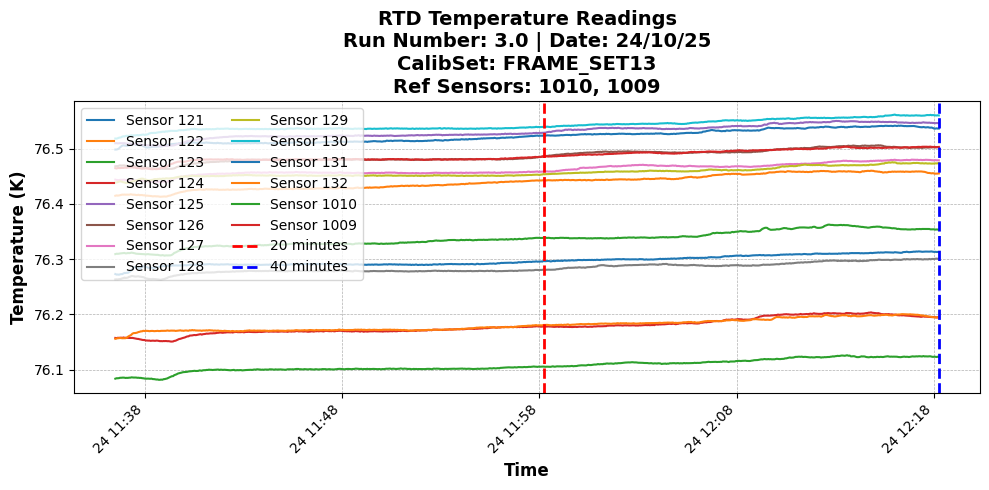

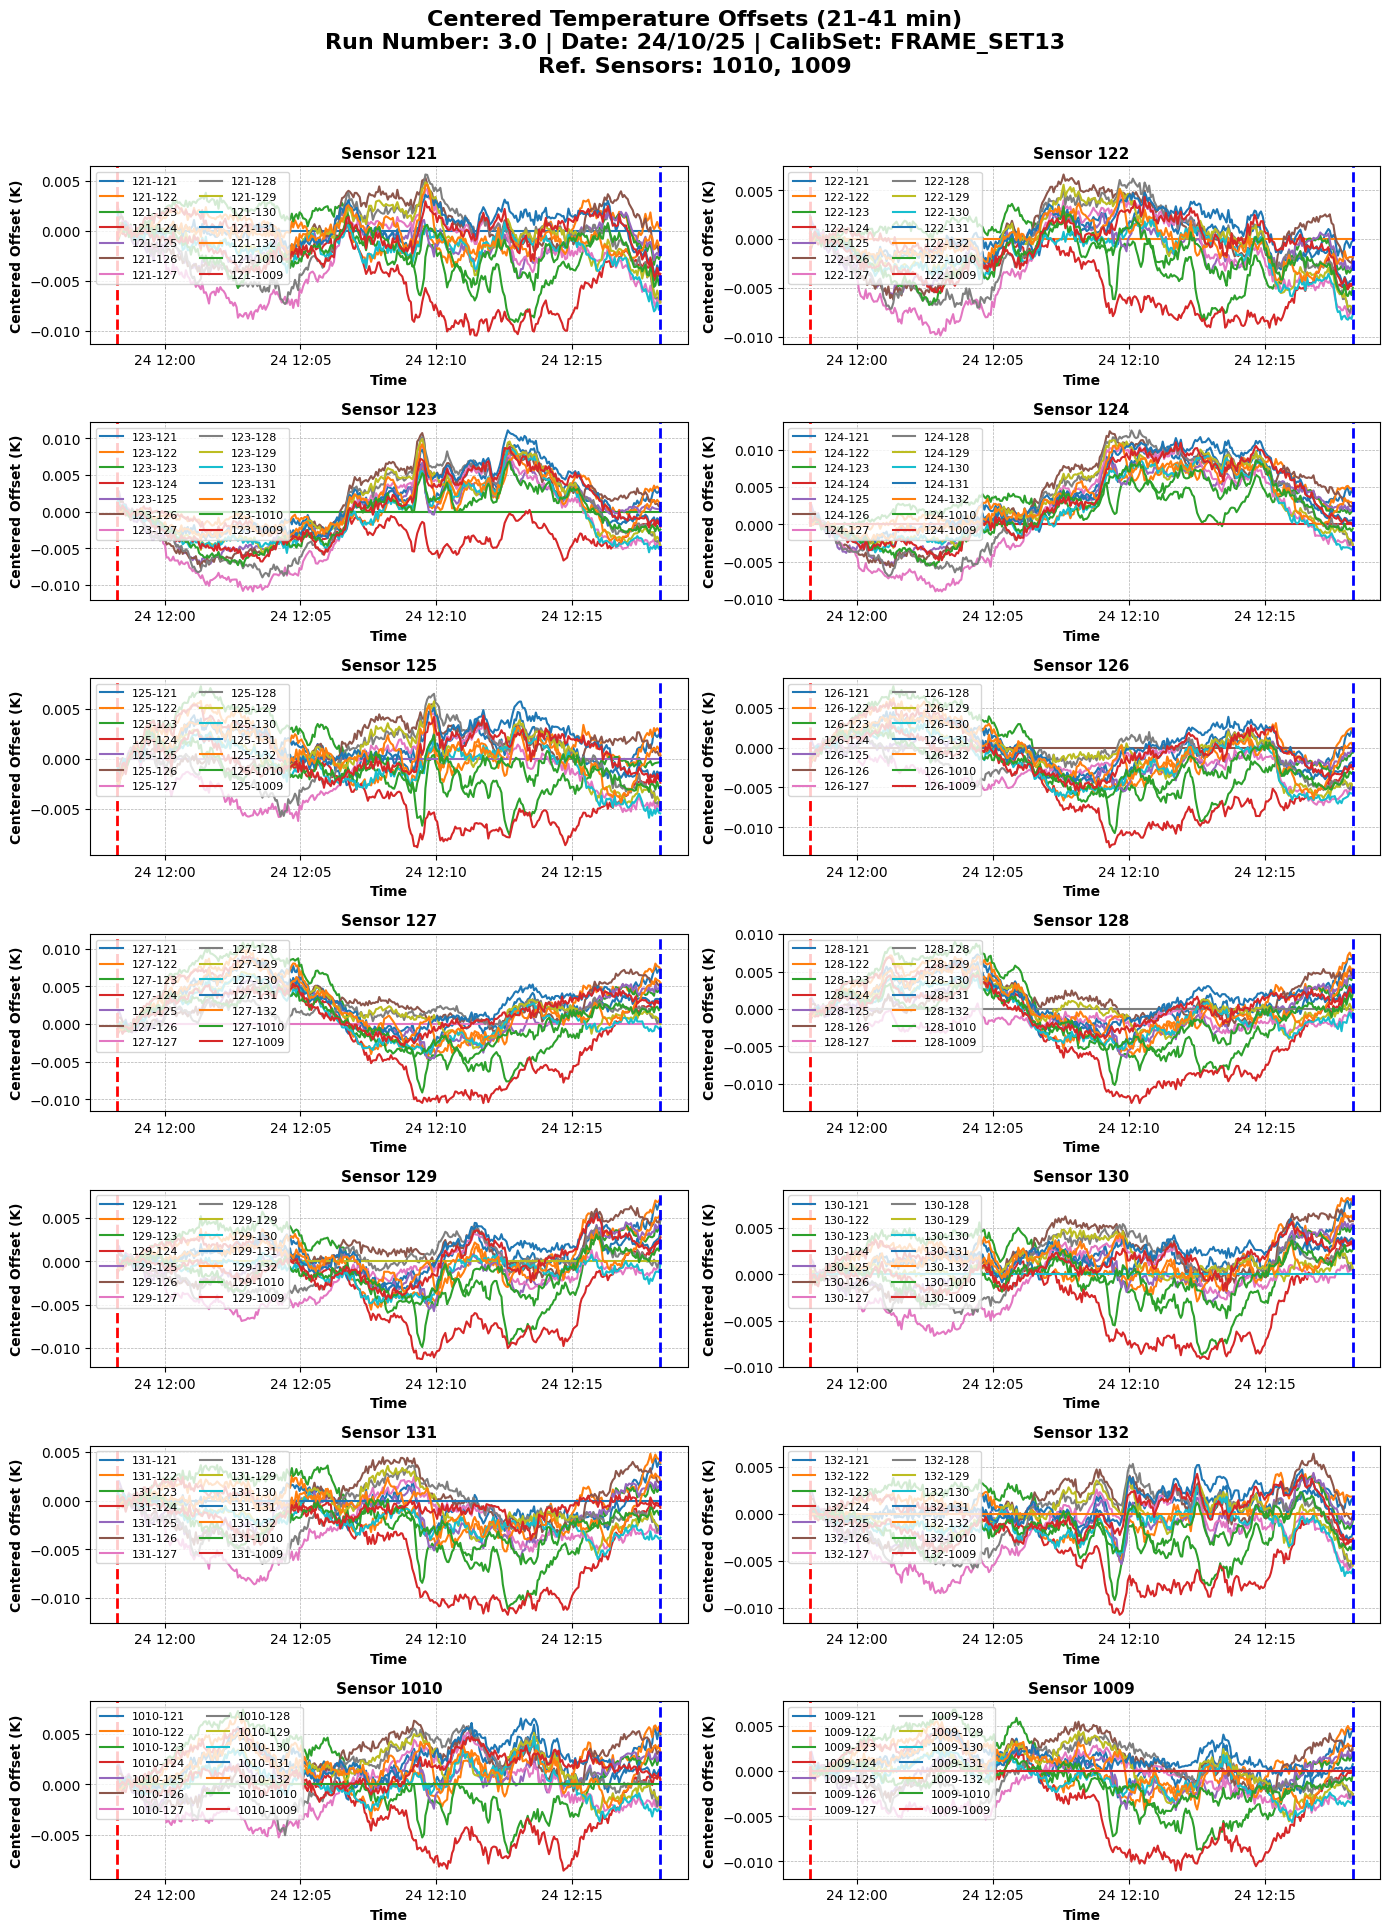

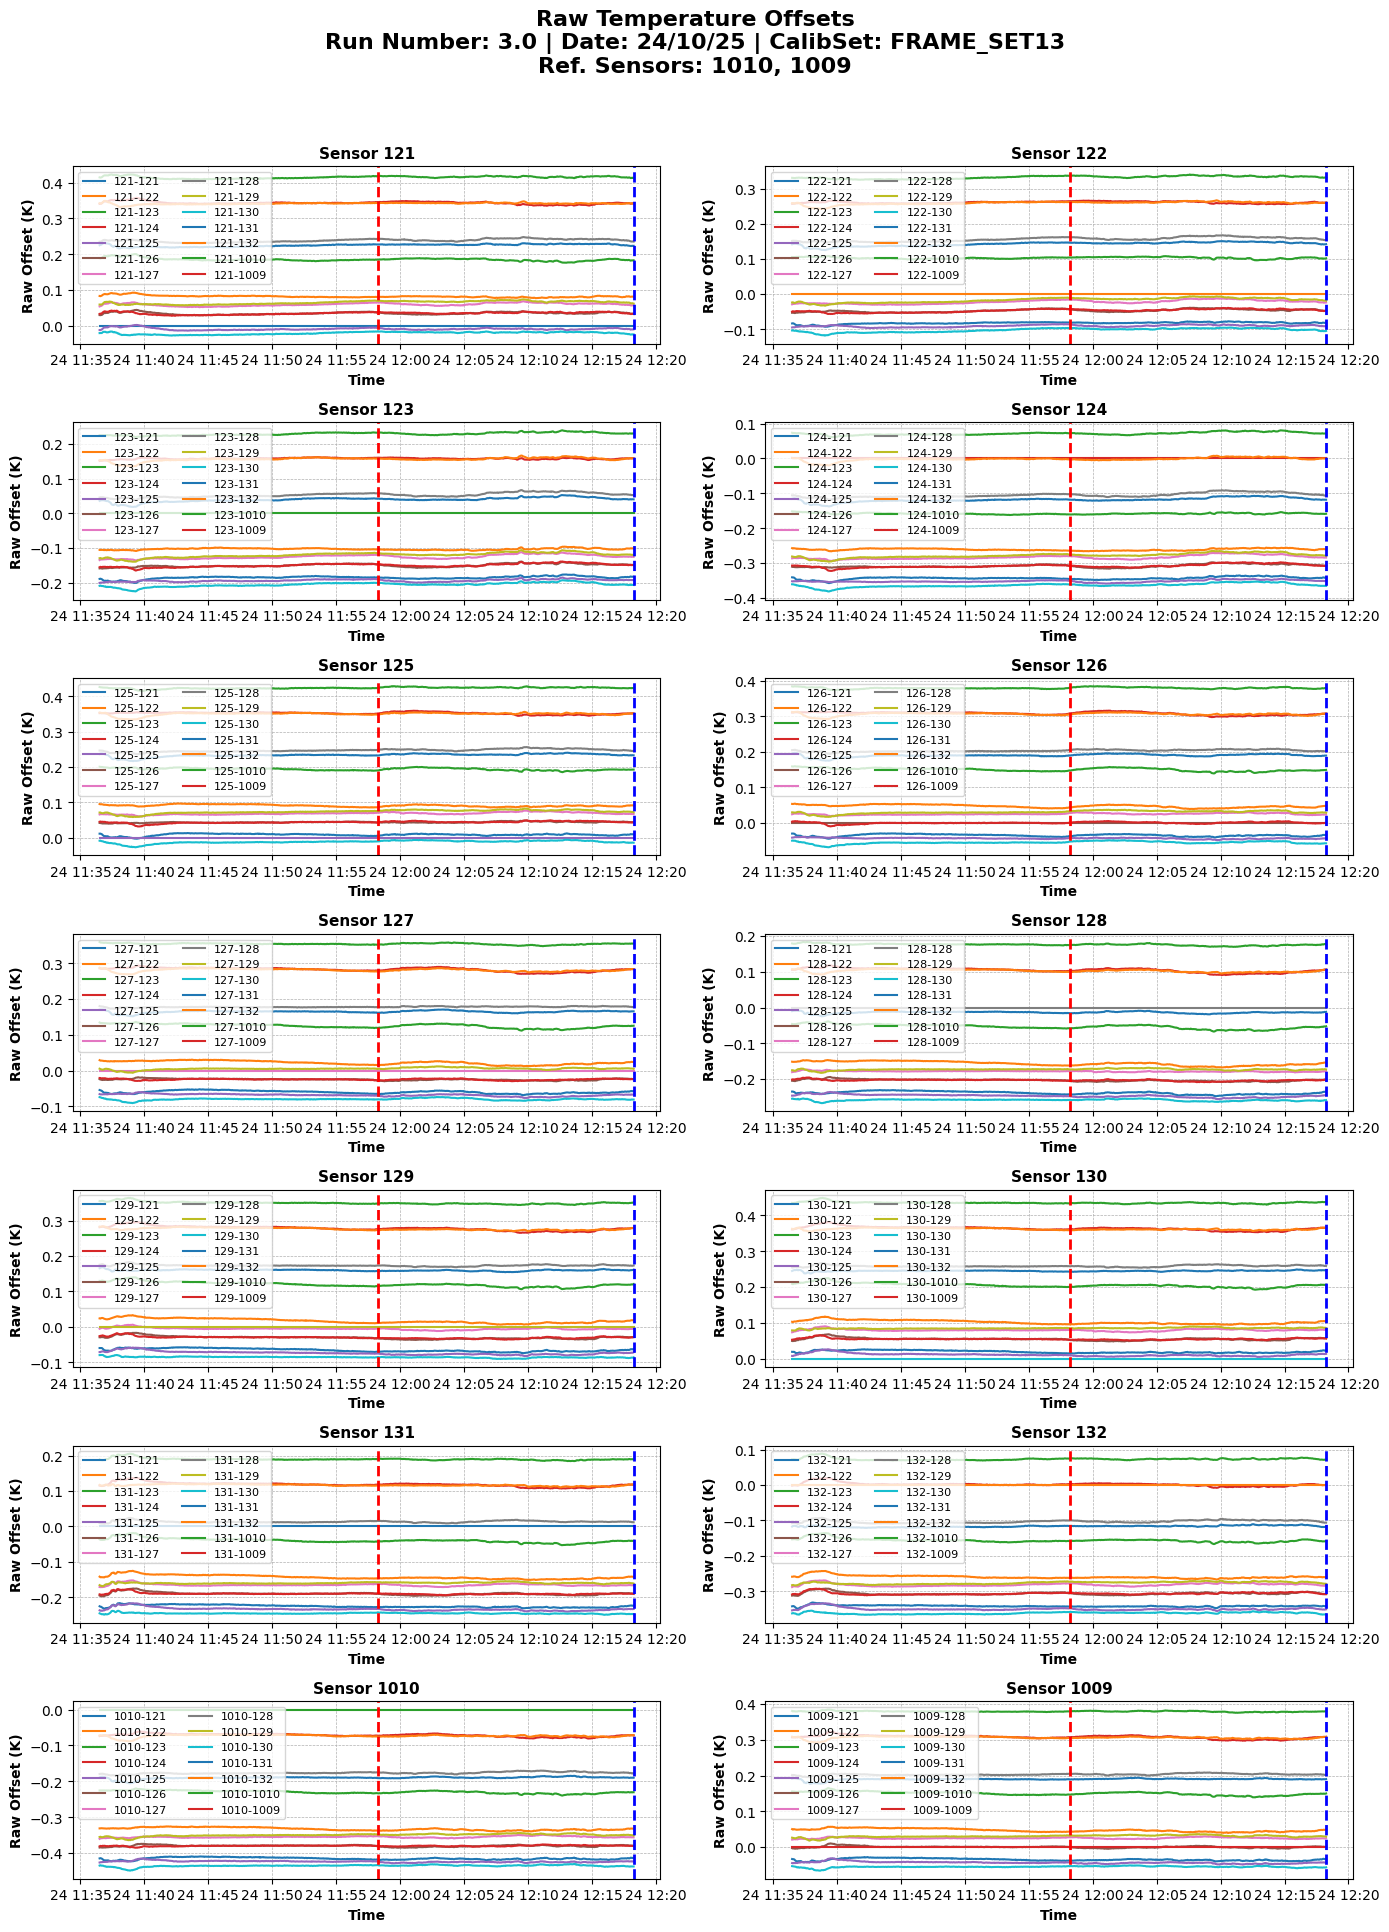

Plots saved in ./Plots/

✅ Plots saved in: ./Plots/


In [5]:
output_dir = "./Plots/"

print(f"\n🔄 Generando plots...\n")
run.save_control_plots(output_dir=output_dir)

print(f"\n✅ Plots saved in: {output_dir}")

In [6]:
print("\n🔄 Calculando offsets...\n")

offsets_df = run.offsets()
print("📊 Matriz de Offsets:")
print(offsets_df)

errors_df = run.stat_err_offsets()
print("\n📊 Errores RMS:")
print(errors_df)


🔄 Calculando offsets...

Offsets medios calculados exitosamente para ventana 20-40 min.
📊 Matriz de Offsets:
           121       122       123       124       125       126       127  \
121   0.000000  0.080913  0.184490  0.342600 -0.008422  0.035919  0.062355   
122  -0.080913  0.000000  0.103576  0.261687 -0.089335 -0.044995 -0.018558   
123  -0.184490 -0.103576  0.000000  0.158110 -0.192911 -0.148571 -0.122135   
124  -0.342600 -0.261687 -0.158110  0.000000 -0.351022 -0.306681 -0.280245   
125   0.008422  0.089335  0.192911  0.351022  0.000000  0.044340  0.070777   
126  -0.035919  0.044995  0.148571  0.306681 -0.044340  0.000000  0.026436   
127  -0.062355  0.018558  0.122135  0.280245 -0.070777 -0.026436  0.000000   
128  -0.241558 -0.160645 -0.057068  0.101042 -0.249980 -0.205639 -0.179203   
129  -0.069211  0.011703  0.115279  0.273389 -0.077632 -0.033292 -0.006855   
130   0.017453  0.098366  0.201943  0.360053  0.009031  0.053372  0.079808   
131  -0.227728 -0.146814 -0.0432


🔄 Generando plot RMS vs tiempo...

Gráfico guardado en: ./Plots/20251024_ln2_STSr10_STSr9_STS121-STS132_3_rms_vs_time.png


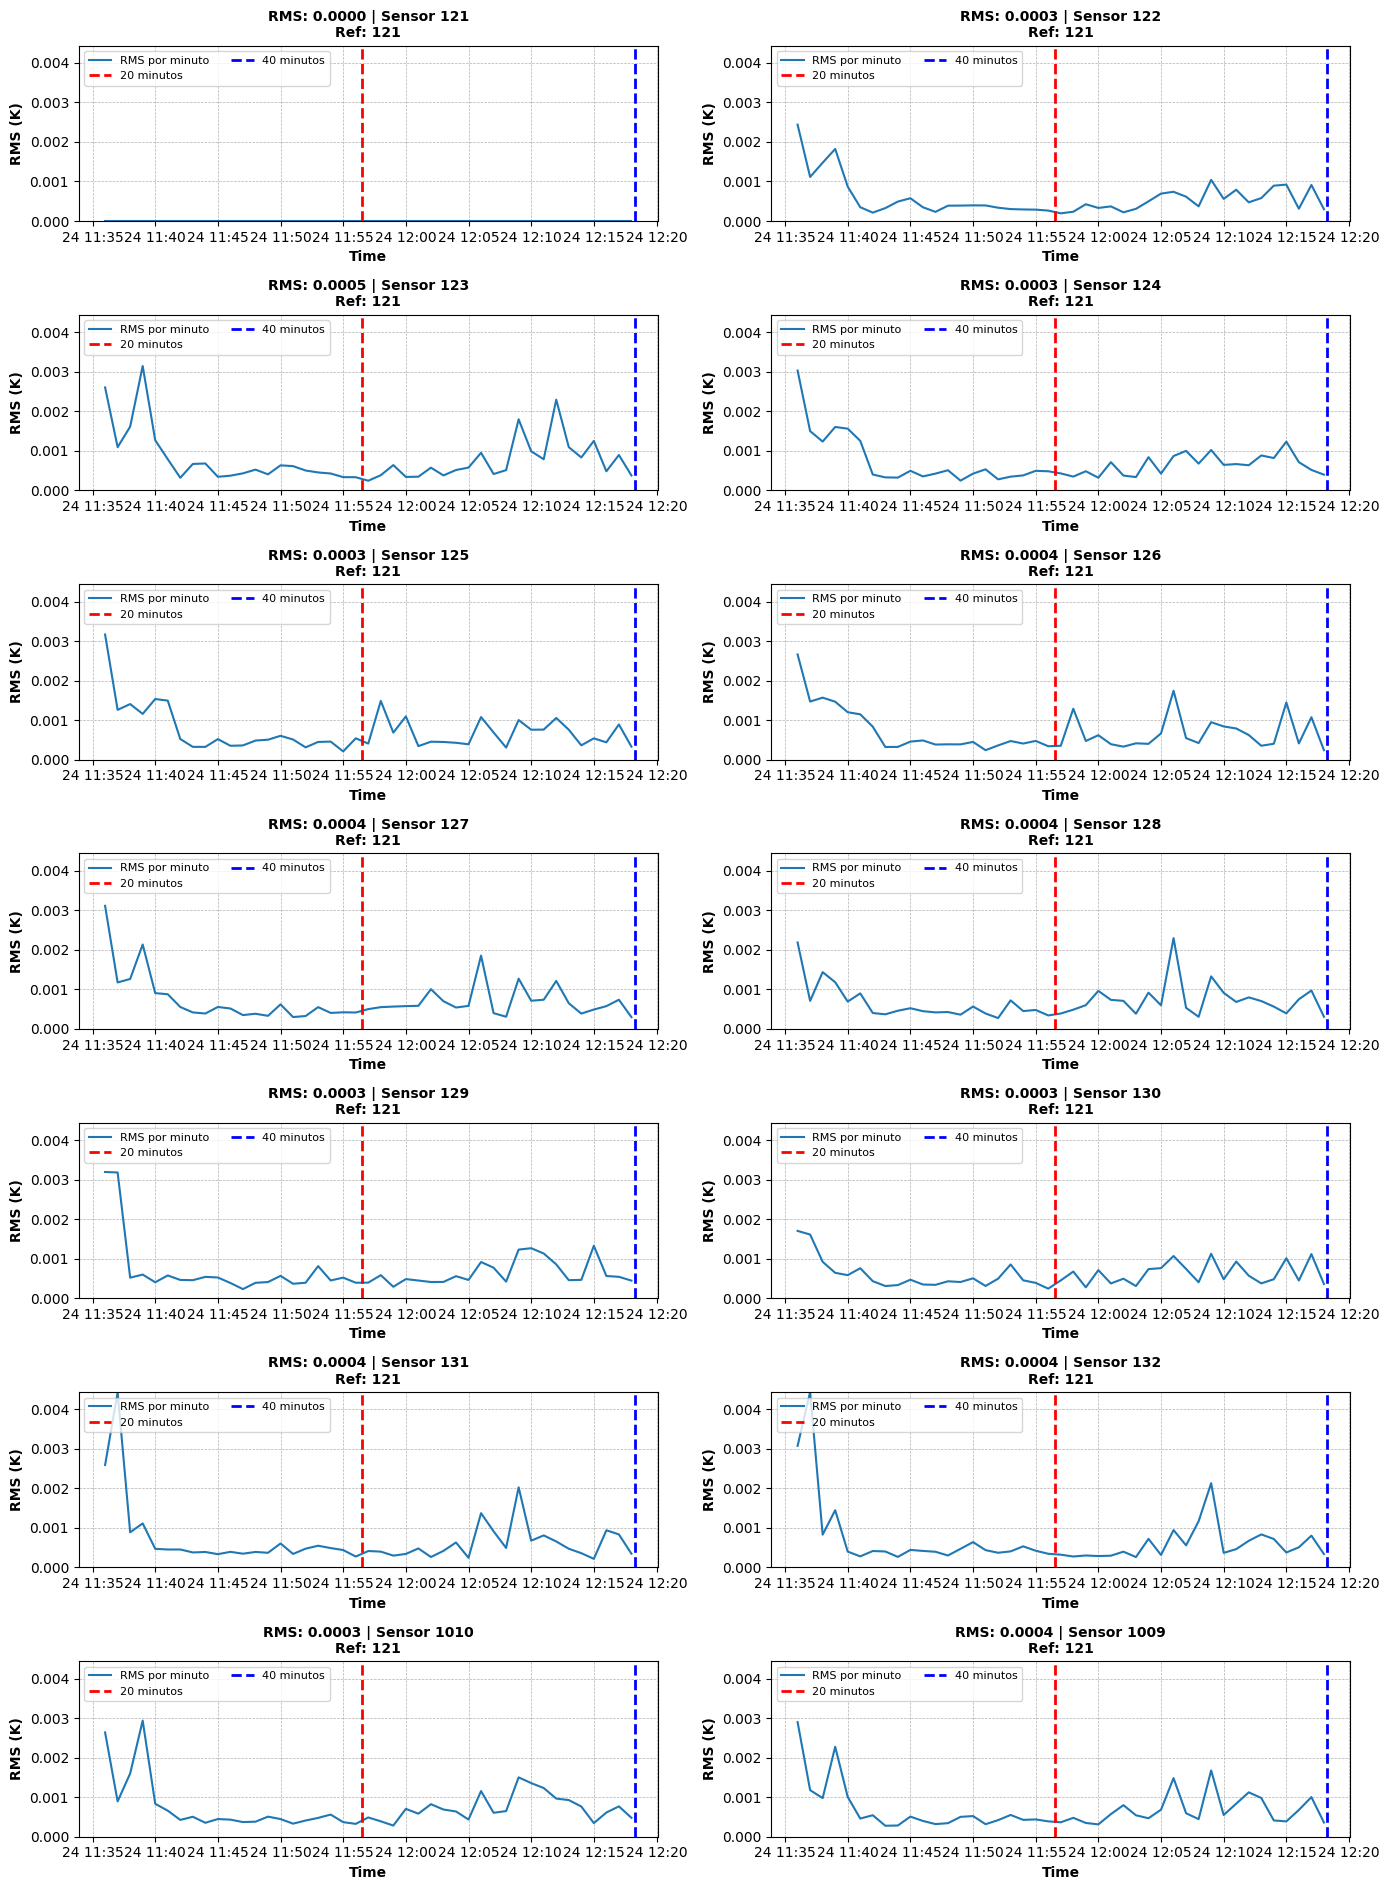


✅ Plot RMS guardado


In [7]:
print("\n🔄 Generando plot RMS vs tiempo...\n")
run.plot_rms_vs_time(output_dir="./Plots/")
print("\n✅ Plot RMS guardado")

In [8]:
# Celda para exploración adicional

# Ver info del run:
# print(f"CalibSetNumber: {run.calib_set_number}")
# print(f"Date: {run.date}")
# print(f"Sensor mapping: {run.sensor_mapping}")

# Ver todos los archivos disponibles:
# for fname in filtered_df['Filename']:
#     print(f"  • {fname}")